# TRACE-RAF Publication-Candidate Results

This notebook reads one manifest-backed final run. It does not train models or alter
predictions. It rejects mixed run identifiers and displays the diagnostics required before
any paper number is updated.


In [1]:
from pathlib import Path, PurePosixPath
import json
import shutil
import sys
import zipfile
import pandas as pd

RESULTS_ROOT_OVERRIDE = None
REQUIRE_FINAL_PUBLICATION_RUN = True
REQUIRE_PUBLICATION_ARTIFACTS_COMPLETE = True

def has_project_files(path):
    return (path / 'configs' / 'default.yaml').exists() and (path / 'src' / 'event_timeraf' / 'config.py').exists()

def reset_directory(path):
    path = path.resolve()
    kaggle_working = Path('/kaggle/working').resolve()
    if path.exists():
        if not path.is_relative_to(kaggle_working):
            raise RuntimeError(f'Refusing to refresh non-working directory: {path}')
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def locate_results_root():
    if RESULTS_ROOT_OVERRIDE is not None:
        override = Path(RESULTS_ROOT_OVERRIDE).resolve()
        if not has_project_files(override):
            raise FileNotFoundError(f'RESULTS_ROOT_OVERRIDE is missing src/event_timeraf/config.py: {override}')
        return override
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, Path('/kaggle/working/event_timeraf')]
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(path.parent.parent for path in kaggle_input.rglob('configs/default.yaml'))
    source = next((path for path in candidates if has_project_files(path)), None)
    if source is None and kaggle_input.exists():
        for archive in sorted(kaggle_input.rglob('*.zip')):
            with zipfile.ZipFile(archive) as bundle:
                members = [PurePosixPath(name) for name in bundle.namelist()]
                config_member = next((member for member in members if member.parts[-2:] == ('configs', 'default.yaml')), None)
                package_member = next((member for member in members if member.parts[-3:] == ('src', 'event_timeraf', 'config.py')), None)
                if config_member is None or package_member is None:
                    continue
                if any(member.is_absolute() or '..' in member.parts for member in members):
                    raise RuntimeError(f'Unsafe paths found in attached archive: {archive}')
                extracted = Path('/kaggle/working/event_timeraf_results_source')
                reset_directory(extracted)
                bundle.extractall(extracted)
                source = extracted.joinpath(*config_member.parts[:-2])
                break
    if source is None:
        raise FileNotFoundError('Set RESULTS_ROOT_OVERRIDE to a completed run directory.')
    if kaggle_input.exists() and source.is_relative_to(kaggle_input):
        writable = Path('/kaggle/working/event_timeraf_results')
        writable.mkdir(parents=True, exist_ok=True)
        for directory in ('configs', 'src', 'outputs'):
            if (source / directory).exists():
                target = writable / directory
                if target.exists():
                    shutil.rmtree(target)
                shutil.copytree(source / directory, target)
        return writable
    return source

PROJECT_ROOT = locate_results_root()
PACKAGE_ROOT = PROJECT_ROOT / 'src' / 'event_timeraf'
if not (PACKAGE_ROOT / 'config.py').exists():
    raise FileNotFoundError(f'Package file missing after setup: {PACKAGE_ROOT / "config.py"}')
for module_name in list(sys.modules):
    if module_name == 'event_timeraf' or module_name.startswith('event_timeraf.'):
        del sys.modules[module_name]
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print({'project_root': str(PROJECT_ROOT), 'package_root': str(PACKAGE_ROOT)})
from event_timeraf.config import load_config
from event_timeraf.plots import plot_horizon_metrics

cfg = load_config(PROJECT_ROOT / 'configs' / 'default.yaml', PROJECT_ROOT)
manifest = json.loads((cfg.paths.outputs / 'logs' / 'run_manifest.json').read_text(encoding='utf-8'))
audit = json.loads((cfg.paths.outputs / 'audit' / 'data_audit.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'metrics.csv')
predictions = pd.read_parquet(cfg.paths.outputs / 'predictions' / 'predictions.parquet')
explanations = pd.read_parquet(cfg.paths.outputs / 'evidence' / 'explanations.parquet')
ablation = pd.read_csv(cfg.paths.outputs / 'tables' / 'ablation_results.csv')
subset_counts = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_counts.csv')
drift_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_period_results.csv')
event_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_period_results.csv')
stride_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'kb_stride_sensitivity.csv')
stride_models = pd.read_csv(cfg.paths.outputs / 'tables' / 'kb_stride_model_sensitivity.csv')
event_weights = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_weight_sensitivity.csv')
event_composition = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_candidate_composition.csv')
event_category_composition = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_category_candidate_composition.csv')
event_weight_models = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_weight_model_sensitivity.csv')
subset_statistics = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_target_statistics.csv')
drift_comparison = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_detector_comparison.csv')
drift_leaf_occupancy = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_leaf_occupancy.csv')
group_faithfulness = pd.read_csv(cfg.paths.outputs / 'tables' / 'validation_group_faithfulness.csv')
attrition = pd.read_csv(cfg.paths.outputs / 'tables' / 'window_origin_attrition.csv')
horizon_skill = pd.read_csv(cfg.paths.outputs / 'tables' / 'horizon_skill_vs_climatology.csv')
exceedance = pd.read_csv(cfg.paths.outputs / 'tables' / 'aqi_exceedance_metrics.csv')
aqi_decision_selection = pd.read_csv(cfg.paths.outputs / 'tables' / 'aqi_decision_threshold_selection.csv')
aqi_calibrated = pd.read_csv(cfg.paths.outputs / 'tables' / 'aqi_calibrated_decision_metrics.csv')
split_protocol = pd.read_csv(cfg.paths.outputs / 'tables' / 'split_protocol.csv')
development_stress = pd.read_csv(
    cfg.paths.outputs / 'tables' / 'development_stress_period_metrics.csv'
)
interval_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_interval_metrics.csv')
placebo_validation = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_placebo_fusion_validation.csv')
log_metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'log_scale_metrics.csv')
quantile_calibration = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_quantile_calibration.csv')
probabilistic_metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_probabilistic_metrics.csv')
neural_training = pd.read_csv(cfg.paths.outputs / 'tables' / 'neural_baseline_training.csv')
feature_control_design = pd.read_csv(cfg.paths.outputs / 'tables' / 'feature_count_control_design.csv')
site_level_sensitivity = pd.read_csv(cfg.paths.outputs / 'tables' / 'site_level_sensitivity.csv')
site_level_design = pd.read_csv(cfg.paths.outputs / 'tables' / 'site_level_design.csv')
site_selection_audit = pd.read_csv(cfg.paths.outputs / 'tables' / 'site_selection_audit.csv')
trace_gate_selection = pd.read_csv(cfg.paths.outputs / 'tables' / 'trace_raf_gate_selection.csv')
trace_design = pd.read_csv(cfg.paths.outputs / 'tables' / 'trace_raf_design.csv')
trace_mechanism = pd.read_csv(
    cfg.paths.outputs / 'tables' / 'trace_raf_mechanism_ablation.csv'
)
trace_oof_audit = pd.read_csv(cfg.paths.outputs / 'tables' / 'trace_raf_oof_audit.csv')
trace_subset_inference = pd.read_csv(cfg.paths.outputs / 'tables' / 'trace_raf_subset_inference.csv')
run_ids = (
    set(metrics['run_id']) | set(predictions['run_id']) | set(explanations['run_id'])
    | set(ablation['run_id']) | set(subset_counts['run_id'])
    | set(drift_results['run_id']) | set(event_results['run_id'])
    | set(stride_results['run_id']) | set(stride_models['run_id'])
    | set(event_weights['run_id']) | set(event_composition['run_id'])
    | set(event_category_composition['run_id'])
    | set(event_weight_models['run_id'])
    | set(subset_statistics['run_id']) | set(drift_comparison['run_id'])
    | set(drift_leaf_occupancy['run_id'])
    | set(group_faithfulness['run_id']) | set(attrition['run_id'])
    | set(horizon_skill['run_id']) | set(exceedance['run_id'])
    | set(aqi_decision_selection['run_id']) | set(aqi_calibrated['run_id'])
    | set(split_protocol['run_id']) | set(development_stress['run_id'])
    | set(interval_results['run_id']) | set(placebo_validation['run_id'])
    | set(log_metrics['run_id']) | set(quantile_calibration['run_id'])
    | set(probabilistic_metrics['run_id']) | set(neural_training['run_id'])
    | set(feature_control_design['run_id'])
    | set(site_level_sensitivity['run_id']) | set(site_level_design['run_id'])
    | set(site_selection_audit['run_id'])
    | set(trace_gate_selection['run_id']) | set(trace_oof_audit['run_id'])
    | set(trace_design['run_id']) | set(trace_mechanism['run_id'])
    | set(trace_subset_inference['run_id'])
)
if run_ids != {manifest['run_id']}:
    raise RuntimeError(f'Mixed or stale run artifacts detected: {sorted(run_ids)} vs manifest {manifest["run_id"]}')
availability_modes = (
    set(metrics['event_availability_mode']) | set(predictions['event_availability_mode'])
    | set(explanations['event_availability_mode'])
)
if availability_modes != {manifest['run_options']['event_availability_mode']}:
    raise RuntimeError(f'Event-availability metadata mismatch: {sorted(availability_modes)}')
run_options = manifest['run_options']
if REQUIRE_FINAL_PUBLICATION_RUN:
    required_true_options = {
        'require_events': run_options.get('require_events'),
        'final_experiment': run_options.get('final_experiment'),
        'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
        'run_tsf_model': run_options.get('run_tsf_model'),
        'stride_model_sweep_completed': run_options.get('stride_model_sweep_completed'),
    }
    failed = [name for name, value in required_true_options.items() if value is not True]
    if failed:
        raise RuntimeError(f'Not a final-publication run; failed manifest options: {failed}')
    if not audit.get('core_ready') or not audit.get('event_ready'):
        raise RuntimeError('Final run failed data-readiness gates in data_audit.json')
if run_options.get('primary_kb_stride_hours') != 24:
    raise RuntimeError('Publication-candidate run must use the primary 24-hour knowledge-base stride.')
if run_options.get('drift_score_mode') != 'two_sided':
    raise RuntimeError('Publication-candidate run must use two-sided drift scoring.')
if run_options.get('bootstrap_block_hours', 0) < 168:
    raise RuntimeError('Publication-candidate inference must use blocks of at least 168 origins.')
if run_options.get('bootstrap_resamples', 0) < 2000:
    raise RuntimeError('Publication-candidate inference must use at least 2,000 resamples.')
if not run_options.get('holm_adjustment'):
    raise RuntimeError('Publication-candidate inference must include Holm multiplicity adjustment.')
if len(ablation) != 2 * run_options.get('paired_comparison_family_size_per_metric', 0):
    raise RuntimeError('Saved paired-inference rows do not match the declared Holm family size.')
if set(run_options.get('placebo_fusion_controls', [])) != {'climatology', 'persistence'}:
    raise RuntimeError('Both Chronos fusion placebo controls are required.')
if set(run_options.get('kb_stride_values', [])) != {1, 6, 24}:
    raise RuntimeError('Publication-candidate run must complete 1/6/24-hour KB sensitivity.')
if not run_options.get('journal_baselines_completed'):
    raise RuntimeError('DLinear, LSTM, PatchTST, and LightGBM baselines are required.')
if not run_options.get('event_weight_model_sweep_completed'):
    raise RuntimeError('The learned event-weight sweep is required.')
if not run_options.get('matched_feature_count_control'):
    raise RuntimeError('The matched event-feature-count control is required.')
if not run_options.get('site_level_sensitivity_completed'):
    raise RuntimeError('The three-monitor site-level sensitivity arm is required.')
if not run_options.get('trace_raf_completed') or not run_options.get('trace_raf_oof_embargo_passed'):
    raise RuntimeError('TRACE-RAF and its out-of-fold temporal embargo are required.')
if not run_options.get('trace_mechanism_ablation_completed'):
    raise RuntimeError('The TRACE raw/residual/gate mechanism ladder is required.')
if not run_options.get('chronos_native_quantile_grid'):
    raise RuntimeError('Chronos probabilistic evaluation must use only its native quantile grid.')
expected_stride_rows = 3 * len(run_options.get('kb_stride_values', []))
if len(stride_models) != expected_stride_rows:
    raise RuntimeError('The learned 1/6/24-hour stride table is incomplete.')
if not run_options.get('trace_raf_stride_selection_completed'):
    raise RuntimeError('TRACE-RAF residual-memory stride selection is incomplete.')
if set(run_options.get('trace_raf_stride_values', [])) != {1, 6, 24}:
    raise RuntimeError('TRACE-RAF must select residual-memory density from 1/6/24-hour strides.')
if not run_options.get('explicit_final_holdout'):
    raise RuntimeError('Final publication claims require an explicit chronological holdout.')
if run_options.get('test_start_date') != cfg.forecast.test_start_date:
    raise RuntimeError('Manifest and configured final-holdout boundaries disagree.')
if (
    run_options.get('development_stress_period') != 'january_2025'
    or run_options.get('development_stress_role') != 'validation_only_not_final_holdout'
):
    raise RuntimeError('January 2025 development-stress role is missing or mislabeled.')
if not run_options.get('aqi_validation_calibration_completed'):
    raise RuntimeError('Validation-calibrated AQI decision evaluation is incomplete.')
if REQUIRE_PUBLICATION_ARTIFACTS_COMPLETE and not run_options.get('publication_artifacts_complete'):
    raise RuntimeError('Publication artifact-completeness gate did not pass.')
print({
    'run_id': manifest['run_id'],
    'event_availability_mode': run_options['event_availability_mode'],
    'final_experiment': run_options.get('final_experiment'),
    'run_tsf_model': run_options.get('run_tsf_model'),
        'stride_model_sweep_completed': run_options.get('stride_model_sweep_completed'),
    'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
    'publication_artifacts_complete': run_options.get('publication_artifacts_complete'),
    'explicit_final_holdout': run_options.get('explicit_final_holdout'),
    'test_start_date': run_options.get('test_start_date'),
    'trace_selected_stride': run_options.get('trace_raf_selected_residual_kb_stride_hours'),
})


{'project_root': '/kaggle/working/event_timeraf_results', 'package_root': '/kaggle/working/event_timeraf_results/src/event_timeraf'}
{'run_id': '20260827T043457543402Z', 'event_availability_mode': 'retrospective_event_start', 'final_experiment': True, 'run_tsf_model': True, 'stride_model_sweep_completed': True, 'retrieval_evidence_reviewed': True, 'publication_artifacts_complete': True, 'explicit_final_holdout': True, 'test_start_date': '2025-08-25', 'trace_selected_stride': 24}


,run_id,model,subset,event_availability_mode,n_origins,n_points,horizon,mse,mae,rmse,mape,smape,r2
1820,20260827T043457543402Z,C01_ridge_context,all,retrospective_event_start,2460,59040,overall,39.144471,4.079278,6.256554,64.069777,38.226796,0.457050
2366,20260827T043457543402Z,B02_lstm,all,retrospective_event_start,2460,59040,overall,39.978172,4.094546,6.322829,62.838283,37.479163,0.445487
4004,20260827T043457543402Z,M13_trace_raf,all,retrospective_event_start,2460,59040,overall,40.062151,4.134315,6.329467,67.442003,38.230536,0.444322
4732,20260827T043457543402Z,A03_trace_raf_no_event,all,retrospective_event_start,2460,59040,overall,40.062241,4.134615,6.329474,67.446401,38.232689,0.444320
2002,20260827T043457543402Z,C05_lightgbm_context,all,retrospective_event_start,2460,59040,overall,40.088786,4.151403,6.331571,67.911049,38.390883,0.443952
4550,20260827T043457543402Z,A06_trace_residual_constant,all,retrospective_event_start,2460,59040,overall,40.114545,4.155516,6.333604,68.313769,38.441203,0.443595
4186,20260827T043457543402Z,A04_trace_raw_analogue_fusion,all,retrospective_event_start,2460,59040,overall,40.114545,4.155516,6.333604,68.313769,38.441203,0.443595
2730,20260827T043457543402Z,C06_context_ensemble,all,retrospective_event_start,2460,59040,overall,40.114545,4.155516,6.333604,68.313769,38.441203,0.443595
2184,20260827T043457543402Z,B00_dlinear,all,retrospective_event_start,2460,59040,overall,40.304908,4.097433,6.348615,64.358204,37.837279,0.440955
2548,20260827T043457543402Z,B01_patchtst,all,retrospective_event_start,2460,59040,overall,40.766248,4.111122,6.384845,63.204963,38.031695,0.434556


,run_id,subset,n_origins,eligible_for_metrics
0,20260827T043457543402Z,event,33,False
1,20260827T043457543402Z,non_event,2427,True
2,20260827T043457543402Z,recent_event,70,True
3,20260827T043457543402Z,active_event,8,False
4,20260827T043457543402Z,event_context,70,True
5,20260827T043457543402Z,non_event_context,2390,True
6,20260827T043457543402Z,drift,407,True
7,20260827T043457543402Z,non_drift,2053,True


,run_id,stage_order,stage,count,removed_since_previous,retained_fraction_of_bounded_origins,criterion
0,20260827T043457543402Z,1,source_hourly_rows,61368,0,NaN,Hourly rows in the aligned modeling table
1,20260827T043457543402Z,2,bounded_candidate_origins,61177,191,1.000000,Origins with a complete history/future time bound
2,20260827T043457543402Z,3,chronological_split_eligible,61129,48,0.999215,Targets do not cross split boundaries
3,20260827T043457543402Z,4,complete_lookback,61121,8,0.999085,No missing PM2.5 value in the 168-hour input
4,20260827T043457543402Z,5,complete_observed_target,60953,168,0.996338,All 24 target values are directly observed
5,20260827T043457543402Z,6,complete_origin_features,56194,4759,0.918548,All causal origin features are finite
6,20260827T043457543402Z,7,complete_future_calendar,56194,0,0.918548,All known-future calendar values are finite
7,20260827T043457543402Z,8,retained_windows,56194,0,0.918548,WindowDataset rows used by the experiment


,run_id,subset,n_origins,target_mean,target_variance,climatology_mse,M04_skill_vs_climatology,M09_skill_vs_climatology
0,20260827T043457543402Z,all,2460,11.003887,72.095932,73.915312,0.431706,0.442705
1,20260827T043457543402Z,event,33,5.011427,7.435599,58.090459,0.526280,0.551585
2,20260827T043457543402Z,non_event,2427,11.085368,72.480225,74.130483,0.430698,0.441544
3,20260827T043457543402Z,recent_event,70,6.339405,11.416567,38.369767,0.824264,0.830660
4,20260827T043457543402Z,active_event,8,3.815625,3.133766,67.643846,0.856473,0.884747
5,20260827T043457543402Z,event_context,70,6.260297,11.264106,39.148468,0.822017,0.829263
6,20260827T043457543402Z,non_event_context,2390,11.142821,73.199280,74.933587,0.425733,0.436790
7,20260827T043457543402Z,drift,407,10.555457,105.341957,109.558546,0.506010,0.529887
8,20260827T043457543402Z,non_drift,2053,11.092787,65.457260,66.849166,0.407564,0.414379


,run_id,comparison,comparison_family,metric,difference,ci_low,ci_high,bootstrap_p_value,block_length,resamples,dm_statistic,dm_p_value,dm_hac_lags,bootstrap_p_value_holm,dm_p_value_holm,significant_dm_holm_0_05
0,20260827T043457543402Z,M04_minus_M03_weather_calendar,component_and_placebo_tests,mse,-2.541527,-6.695449,0.940068,0.187163,168,5000,-1.304644,0.192014,168,1.000000,1.000000,False
1,20260827T043457543402Z,M04_minus_M03_weather_calendar,component_and_placebo_tests,mae,-0.084732,-0.230350,0.081409,0.281544,168,5000,-1.058402,0.289872,168,1.000000,1.000000,False
2,20260827T043457543402Z,M07_minus_M04_cosine_retrieval,component_and_placebo_tests,mse,-1.071151,-2.280298,-0.041208,0.059788,168,5000,-1.843556,0.065248,168,1.000000,1.000000,False
3,20260827T043457543402Z,M07_minus_M04_cosine_retrieval,component_and_placebo_tests,mae,-0.075721,-0.132472,-0.026124,0.007798,168,5000,-2.726441,0.006402,168,0.202759,0.166455,False
4,20260827T043457543402Z,M08_minus_M07_event_conditioning,component_and_placebo_tests,mse,0.150664,-0.446565,0.788711,0.635473,168,5000,0.484227,0.628225,168,1.000000,1.000000,False
5,20260827T043457543402Z,M08_minus_M07_event_conditioning,component_and_placebo_tests,mae,-0.020873,-0.056195,0.011466,0.221956,168,5000,-1.203206,0.228897,168,1.000000,1.000000,False
6,20260827T043457543402Z,M09_minus_M08_drift_features,component_and_placebo_tests,mse,0.107499,-0.386416,0.502395,0.632873,168,5000,0.471572,0.637232,168,1.000000,1.000000,False
7,20260827T043457543402Z,M09_minus_M08_drift_features,component_and_placebo_tests,mae,0.011933,-0.008793,0.030763,0.235953,168,5000,1.178243,0.238700,168,1.000000,1.000000,False
8,20260827T043457543402Z,M09_minus_A00_events,component_and_placebo_tests,mse,0.343563,-0.284538,1.151766,0.361128,168,5000,0.944149,0.345093,168,1.000000,1.000000,False
9,20260827T043457543402Z,M09_minus_A00_events,component_and_placebo_tests,mae,-0.002787,-0.028412,0.023018,0.830034,168,5000,-0.214940,0.829814,168,1.000000,1.000000,False


...

,run_id,period,evaluation_role,model,origin_start,origin_end,n_origins,mse,mae,rmse,mape,smape,r2,climatology_mse,skill_vs_climatology
10,20260827T043457543402Z,january_2025,development_stress_analysis,B00_dlinear,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,109.606804,7.324979,10.469327,82.864375,48.343535,0.369935,177.167158,0.381337
11,20260827T043457543402Z,january_2025,development_stress_analysis,B02_lstm,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,114.154798,7.542139,10.684325,89.844948,49.268372,0.343791,177.167158,0.355666
26,20260827T043457543402Z,january_2025,development_stress_analysis,M10_frozen_chronos,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,116.012121,6.777293,10.770892,65.351464,43.986519,0.333114,177.167158,0.345183
12,20260827T043457543402Z,january_2025,development_stress_analysis,B01_patchtst,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,118.010442,7.650312,10.863261,95.545560,49.706131,0.321627,177.167158,0.333903
8,20260827T043457543402Z,january_2025,development_stress_analysis,C01_ridge_context,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,118.299598,7.142601,10.876562,83.970160,47.854648,0.319965,177.167158,0.332271
17,20260827T043457543402Z,january_2025,development_stress_analysis,M08_event_timeraf_no_drift,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,122.797077,7.009768,11.081384,71.542577,45.956940,0.294111,177.167158,0.306886
30,20260827T043457543402Z,january_2025,development_stress_analysis,M12_validation_drift_router,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,122.915010,6.990901,11.086704,70.601316,45.648523,0.293433,177.167158,0.306220
13,20260827T043457543402Z,january_2025,development_stress_analysis,C06_context_ensemble,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,123.304585,6.783979,11.104260,64.941734,44.424418,0.291194,177.167158,0.304021
21,20260827T043457543402Z,january_2025,development_stress_analysis,A04_trace_raw_analogue_fusion,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,123.304585,6.783979,11.104260,64.941734,44.424418,0.291194,177.167158,0.304021
23,20260827T043457543402Z,january_2025,development_stress_analysis,A06_trace_residual_constant,2025-01-01 00:00:00+00:00,2025-01-31 23:00:00+00:00,622,123.304585,6.783979,11.104260,64.941734,44.424418,0.291194,177.167158,0.304021


,run_id,model,nominal_coverage,empirical_coverage,mean_width,winkler_interval_score,lower_pinball_loss,upper_pinball_loss,n_points
0,20260827T043457543402Z,M10_frozen_chronos,0.8,0.761416,12.526620,19.881577,0.764178,1.223979,59040
1,20260827T043457543402Z,M11_chronos_event_retrieval,0.8,0.205877,3.131655,35.572998,1.728372,1.828928,59040


,run_id,model,transform,n_points,mse,mae,rmse,mape,smape,r2
13,20260827T043457543402Z,B02_lstm,log1p_nonnegative,59040,0.217257,0.346356,0.466108,21.121447,16.196371,0.454498
10,20260827T043457543402Z,C01_ridge_context,log1p_nonnegative,59040,0.220260,0.352841,0.469319,21.688762,16.574480,0.446956
31,20260827T043457543402Z,P01_chronos_persistence_fusion,log1p_nonnegative,59040,0.225933,0.357701,0.475324,20.147800,16.817206,0.432714
14,20260827T043457543402Z,B01_patchtst,log1p_nonnegative,59040,0.226046,0.351830,0.475443,21.382994,16.547507,0.432430
12,20260827T043457543402Z,B00_dlinear,log1p_nonnegative,59040,0.226618,0.350633,0.476044,21.542321,16.457053,0.430994
28,20260827T043457543402Z,M10_frozen_chronos,log1p_nonnegative,59040,0.227727,0.353985,0.477207,20.443441,16.624508,0.428208
19,20260827T043457543402Z,M08_event_timeraf_no_drift,log1p_nonnegative,59040,0.230333,0.353691,0.479930,21.807547,16.500966,0.421665
21,20260827T043457543402Z,M09_event_timeraf_full,log1p_nonnegative,59040,0.231910,0.355026,0.481571,21.889646,16.560049,0.417704
16,20260827T043457543402Z,M07_xgb_cosine,log1p_nonnegative,59040,0.232290,0.355826,0.481965,22.013377,16.598007,0.416750
27,20260827T043457543402Z,A00_full_without_events,log1p_nonnegative,59040,0.232578,0.355861,0.482264,22.008475,16.603511,0.416027


,run_id,model,quantile_grid,crps_quantile_approximation,mean_absolute_calibration_error,monotonicity_correction_fraction,n_points
0,20260827T043457543402Z,M10_frozen_chronos,"0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90",3.187069,0.017028,0.0,59040
1,20260827T043457543402Z,M11_chronos_event_retrieval,"0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90",4.119503,0.175772,0.0,59040


,run_id,model,quantile,empirical_cdf,calibration_error,pinball_loss,n_points
0,20260827T043457543402Z,M10_frozen_chronos,0.1,0.122409,0.022409,0.764178,59040
1,20260827T043457543402Z,M10_frozen_chronos,0.2,0.229607,0.029607,1.293280,59040
2,20260827T043457543402Z,M10_frozen_chronos,0.3,0.327727,0.027727,1.683468,59040
3,20260827T043457543402Z,M10_frozen_chronos,0.4,0.419919,0.019919,1.949751,59040
4,20260827T043457543402Z,M10_frozen_chronos,0.5,0.512263,0.012263,2.100932,59040
5,20260827T043457543402Z,M10_frozen_chronos,0.6,0.603066,0.003066,2.134218,59040
6,20260827T043457543402Z,M10_frozen_chronos,0.7,0.693547,-0.006453,2.032230,59040
7,20260827T043457543402Z,M10_frozen_chronos,0.8,0.784909,-0.015091,1.759227,59040
8,20260827T043457543402Z,M10_frozen_chronos,0.9,0.883283,-0.016717,1.223979,59040
9,20260827T043457543402Z,M11_chronos_event_retrieval,0.1,0.456013,0.356013,1.728372,59040


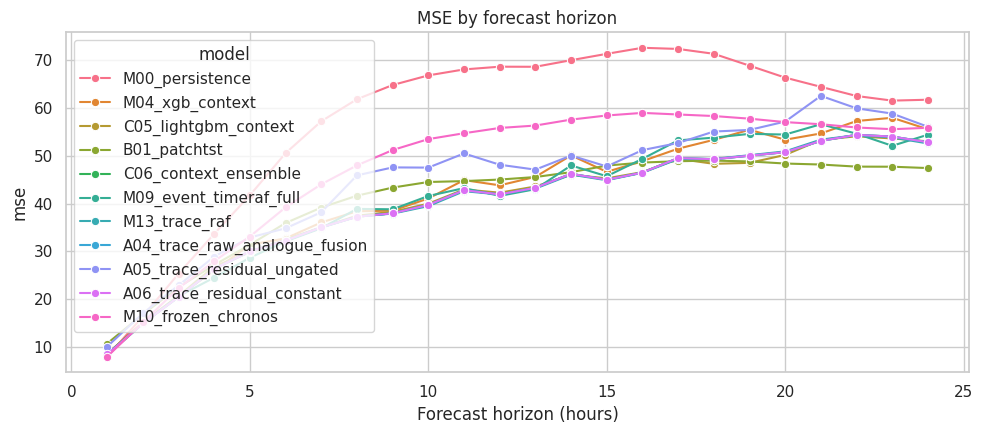

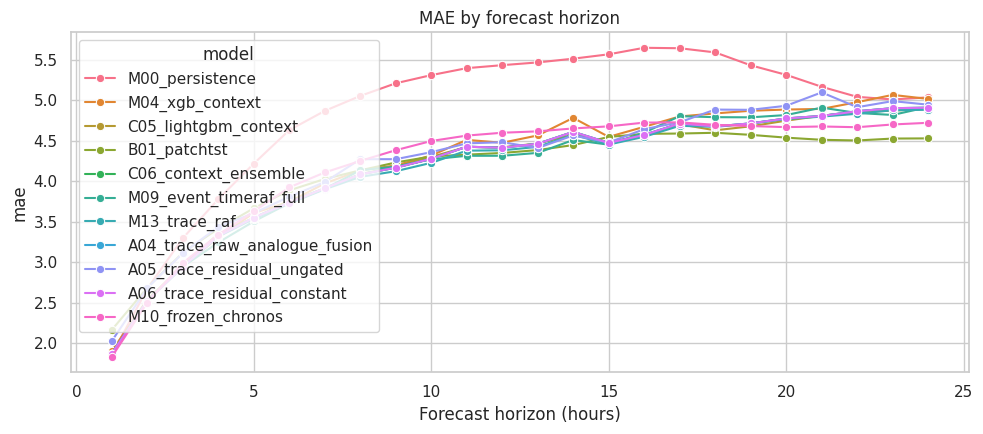

In [2]:
overall = metrics.loc[
    (metrics['horizon'].astype(str) == 'overall') & (metrics['subset'] == 'all')
].sort_values('mse')
display(overall)
comparison_models = [
    'M00_persistence', 'M04_xgb_context', 'C05_lightgbm_context',
    'C06_context_ensemble', 'M09_event_timeraf_full',
    'A04_trace_raw_analogue_fusion', 'A05_trace_residual_ungated',
    'A06_trace_residual_constant', 'M13_trace_raf',
    'B01_patchtst', 'M10_frozen_chronos',
]
comparison_metrics = metrics.loc[metrics['model'].isin(comparison_models)]
plot_horizon_metrics(comparison_metrics, 'mse')
plot_horizon_metrics(comparison_metrics, 'mae')
display(subset_counts)
display(attrition)
display(subset_statistics)
display(ablation)
display(exceedance)
display(aqi_decision_selection)
display(aqi_calibrated)
display(split_protocol)
display(development_stress.sort_values('mse'))
display(interval_results)
display(log_metrics.sort_values('mse'))
display(probabilistic_metrics)
display(quantile_calibration)


In [3]:
display(stride_results.sort_values(['method', 'stride_hours']))
display(stride_models.sort_values(['model', 'stride_hours']))
display(event_weights.sort_values(['subset', 'event_weight']))
display(event_composition)
display(event_category_composition)
display(event_weight_models.sort_values(['split', 'event_weight']))
display(placebo_validation.loc[placebo_validation['selected_on_validation']])
display(group_faithfulness.sort_values('mse_increase', ascending=False))
display(horizon_skill.sort_values(['model', 'horizon']))
display(neural_training.loc[neural_training['selected_epoch']])
display(feature_control_design)
display(site_level_design)
display(site_selection_audit)
display(site_level_sensitivity)
display(trace_oof_audit)
display(trace_design)
display(trace_mechanism.sort_values('model'))
display(trace_gate_selection.sort_values(['model', 'gate_strength']))
display(trace_subset_inference.sort_values(['subset', 'comparison', 'metric']))
display(drift_comparison)
display(drift_leaf_occupancy)
display(drift_results)
display(event_results)
display(explanations.sort_values('drift_score', ascending=False).head(10))


,run_id,stride_hours,method,candidate_count,runtime_seconds,minimum_eligible_candidates,mse,mae,rmse,mape,smape,r2
7,20260827T043457543402Z,1,cosine,45784,71.742758,45784,52.738031,4.764438,7.262095,70.005523,43.977685,0.268502
4,20260827T043457543402Z,6,cosine,7608,23.151764,7608,49.523917,4.648843,7.037323,70.995571,42.833983,0.313083
1,20260827T043457543402Z,24,cosine,1824,0.000006,1824,53.548613,4.859697,7.317692,73.006566,44.414402,0.257259
8,20260827T043457543402Z,1,event_conditioned,45784,71.742758,45784,54.253500,4.839539,7.365698,73.225653,44.435742,0.247482
5,20260827T043457543402Z,6,event_conditioned,7608,23.151764,7608,47.854748,4.598034,6.917713,70.645113,42.818214,0.336235
2,20260827T043457543402Z,24,event_conditioned,1824,0.000006,1824,54.097525,4.909177,7.355102,74.200441,44.761280,0.249645
6,20260827T043457543402Z,1,random,45784,71.742758,45784,67.623700,5.632747,8.223363,96.249784,50.046867,0.062032
3,20260827T043457543402Z,6,random,7608,23.151764,7608,69.162295,5.685033,8.316387,96.550466,50.440125,0.040691
0,20260827T043457543402Z,24,random,1824,0.000006,1824,70.093724,5.742325,8.372199,96.928336,50.978214,0.027772


,run_id,stride_hours,model,mse,mae,rmse,mape,smape,r2
6,20260827T043457543402Z,1,M07_xgb_cosine,42.001036,4.176606,6.480821,66.511496,38.367448,0.417429
3,20260827T043457543402Z,6,M07_xgb_cosine,40.853685,4.134545,6.391689,67.026637,38.163069,0.433343
0,20260827T043457543402Z,24,M07_xgb_cosine,40.934500,4.156980,6.398008,66.886958,38.296143,0.432222
7,20260827T043457543402Z,1,M08_event_timeraf_no_drift,41.171945,4.167085,6.416537,66.983981,38.486334,0.428928
4,20260827T043457543402Z,6,M08_event_timeraf_no_drift,40.520252,4.132986,6.365552,66.962091,38.254365,0.437968
1,20260827T043457543402Z,24,M08_event_timeraf_no_drift,41.085164,4.136107,6.409771,65.994373,38.079878,0.430132
8,20260827T043457543402Z,1,M09_event_timeraf_full,41.748942,4.199365,6.461342,67.877275,38.743609,0.420925
5,20260827T043457543402Z,6,M09_event_timeraf_full,40.886178,4.145214,6.394230,67.211340,38.381805,0.432892
2,20260827T043457543402Z,24,M09_event_timeraf_full,41.192663,4.148040,6.418151,66.287948,38.211406,0.428641


,run_id,event_weight,subset,n_origins,mse,mae,rmse,mape,smape,r2,selected_candidate_changed_fraction_vs_weight_0
0,20260827T043457543402Z,0.0,all,2460,54.112494,4.911957,7.356119,74.232482,44.809215,0.249438,0.000000
3,20260827T043457543402Z,0.2,all,2460,54.097525,4.909177,7.355102,74.200441,44.761280,0.249645,0.026982
6,20260827T043457543402Z,0.5,all,2460,54.102940,4.909627,7.355470,74.231814,44.765742,0.249570,0.027846
9,20260827T043457543402Z,0.8,all,2460,54.148008,4.915299,7.358533,74.433462,44.831308,0.248945,0.027896
12,20260827T043457543402Z,1.0,all,2460,54.164730,4.917207,7.359669,74.497532,44.852353,0.248713,0.028303
1,20260827T043457543402Z,0.0,event_context,70,12.486734,2.948022,3.533657,70.550412,48.394548,-0.108542,NaN
4,20260827T043457543402Z,0.2,event_context,70,11.960694,2.850314,3.458424,69.424419,46.709978,-0.061841,NaN
7,20260827T043457543402Z,0.5,event_context,70,12.150992,2.866152,3.485827,70.526931,46.866796,-0.078736,NaN
10,20260827T043457543402Z,0.8,event_context,70,13.734799,3.065488,3.706049,77.613414,49.170967,-0.219342,NaN
13,20260827T043457543402Z,1.0,event_context,70,14.322444,3.132526,3.784501,79.865047,49.910561,-0.271512,NaN


,run_id,event_weight,event_context_queries,conditioned_queries,selected_candidate_event_fraction,event_score_zero_fraction
0,20260827T043457543402Z,0.0,70,70,0.111839,0.199593
1,20260827T043457543402Z,0.2,70,70,0.111839,0.196951
2,20260827T043457543402Z,0.5,70,70,0.111839,0.196951
3,20260827T043457543402Z,0.8,70,70,0.111839,0.196951
4,20260827T043457543402Z,1.0,70,70,0.111839,0.196951


,run_id,category,query_origins_with_category,selected_candidates,selected_candidate_category_fraction,knowledge_base_category_fraction
0,20260827T043457543402Z,wildfire,0,0,NaN,0.011513
1,20260827T043457543402Z,smoke,0,0,NaN,0.000000
2,20260827T043457543402Z,excessive_heat,0,0,NaN,0.000000
3,20260827T043457543402Z,high_wind,0,0,NaN,0.087719
4,20260827T043457543402Z,heavy_rain,67,536,0.537313,0.009320
5,20260827T043457543402Z,flood,69,552,0.403986,0.018092
6,20260827T043457543402Z,dust,0,0,NaN,0.000000
7,20260827T043457543402Z,traffic,0,0,NaN,0.000000
8,20260827T043457543402Z,industrial_activity,0,0,NaN,0.000000
9,20260827T043457543402Z,policy,0,0,NaN,0.000000


...

,run_id,detector,threshold,flagged_origins,flag_jaccard
0,20260827T043457543402Z,Event-TimeRAF composite,0.213168,407,0.116864
1,20260827T043457543402Z,KS two-sample,0.452292,348,0.116864


,run_id,model,horizon,state,n_origins,n_trees,occupied_tree_leaf_pairs,mean_same_state_leaf_support,exclusive_assignment_fraction
0,20260827T043457543402Z,M09_event_timeraf_full,1,non_drift,2053,350,9296,692.654794,0.035130
1,20260827T043457543402Z,M09_event_timeraf_full,1,drift,407,350,6952,117.252720,0.019951
2,20260827T043457543402Z,M09_event_timeraf_full,2,non_drift,2053,350,9852,648.983080,0.039058
3,20260827T043457543402Z,M09_event_timeraf_full,2,drift,407,350,7275,107.187926,0.023159
4,20260827T043457543402Z,M09_event_timeraf_full,3,non_drift,2053,350,9778,629.793980,0.039169
5,20260827T043457543402Z,M09_event_timeraf_full,3,drift,407,350,7230,99.982773,0.024086
6,20260827T043457543402Z,M09_event_timeraf_full,4,non_drift,2053,350,9833,604.001133,0.043162
7,20260827T043457543402Z,M09_event_timeraf_full,4,drift,407,350,7292,95.988164,0.027336
8,20260827T043457543402Z,M09_event_timeraf_full,5,non_drift,2053,350,10030,559.307494,0.047625
9,20260827T043457543402Z,M09_event_timeraf_full,5,drift,407,350,7376,88.968101,0.029744


,run_id,model,drift_flag,n_origins,n_points,eligible_for_metrics,mse,mae,skill_vs_climatology,event_availability_mode
0,20260827T043457543402Z,C00_hour_month_climatology,False,2053,49272,True,66.849166,6.038505,0.000000,retrospective_event_start
1,20260827T043457543402Z,C02_calendar_retrieval,False,2053,49272,True,62.439637,5.327577,0.065962,retrospective_event_start
2,20260827T043457543402Z,C03_event_conditioned_retrieval,False,2053,49272,True,51.801460,4.731103,0.225099,retrospective_event_start
3,20260827T043457543402Z,M00_persistence,False,2053,49272,True,48.053694,4.638350,0.281162,retrospective_event_start
4,20260827T043457543402Z,M01_daily_seasonal,False,2053,49272,True,56.024188,4.863036,0.161931,retrospective_event_start
...,...,...,...,...,...,...,...,...,...,...
61,20260827T043457543402Z,M10_frozen_chronos,True,407,9768,True,71.189595,5.131792,0.350214,retrospective_event_start
62,20260827T043457543402Z,M11_chronos_event_retrieval,True,407,9768,True,57.825997,5.390793,0.472191,retrospective_event_start
63,20260827T043457543402Z,P00_chronos_climatology_fusion,True,407,9768,True,59.154018,5.798432,0.460069,retrospective_event_start
64,20260827T043457543402Z,P01_chronos_persistence_fusion,True,407,9768,True,78.513377,5.191529,0.283366,retrospective_event_start


,run_id,model,target_event_flag,n_origins,n_points,eligible_for_metrics,mse,mae,skill_vs_climatology,event_availability_mode
0,20260827T043457543402Z,C00_hour_month_climatology,False,2427,58248,True,74.130483,6.391468,0.000000,retrospective_event_start
1,20260827T043457543402Z,C02_calendar_retrieval,False,2427,58248,True,73.638940,5.845535,0.006631,retrospective_event_start
2,20260827T043457543402Z,C03_event_conditioned_retrieval,False,2427,58248,True,54.632593,4.931291,0.263021,retrospective_event_start
3,20260827T043457543402Z,M00_persistence,False,2427,58248,True,57.914379,4.865624,0.218751,retrospective_event_start
4,20260827T043457543402Z,M01_daily_seasonal,False,2427,58248,True,65.318023,5.154998,0.118878,retrospective_event_start
...,...,...,...,...,...,...,...,...,...,...
61,20260827T043457543402Z,M10_frozen_chronos,True,33,792,False,NaN,NaN,NaN,retrospective_event_start
62,20260827T043457543402Z,M11_chronos_event_retrieval,True,33,792,False,NaN,NaN,NaN,retrospective_event_start
63,20260827T043457543402Z,P00_chronos_climatology_fusion,True,33,792,False,NaN,NaN,NaN,retrospective_event_start
64,20260827T043457543402Z,P01_chronos_persistence_fusion,True,33,792,False,NaN,NaN,NaN,retrospective_event_start


,run_id,window_id,origin_time,explanation,retrieved_evidence_ids,event_evidence_ids,top_feature_effects,drift_components,retrieval_spread,validation_residual_rmse,uncertainty_proxy,drift_score,drift_flag,event_availability_mode
2372,20260827T043457543402Z,w_0061245,2025-12-26 21:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0015080"", ""w_0028808"", ""w_0012008""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.8571442365646362, ""variance_s...",5.214554,5.933234,7.899040,0.470843,True,retrospective_event_start
2367,20260827T043457543402Z,w_0061240,2025-12-26 16:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0036392"", ""w_0043592"", ""w_0028808""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.912347674369812, ""variance_sh...",3.732676,5.933234,7.009717,0.470571,True,retrospective_event_start
2375,20260827T043457543402Z,w_0061248,2025-12-27 00:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0038024"", ""w_0011144"", ""w_0026168""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.8352749943733215, ""variance_s...",5.566516,5.933234,8.135685,0.470068,True,retrospective_event_start
2366,20260827T043457543402Z,w_0061239,2025-12-26 15:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0043592"", ""w_0036392"", ""w_0015080""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.9202418327331543, ""variance_s...",4.002502,5.933234,7.157045,0.462369,True,retrospective_event_start
2373,20260827T043457543402Z,w_0061246,2025-12-26 22:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0011144"", ""w_0038024"", ""w_0026168""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.8538249135017395, ""variance_s...",4.109259,5.933234,7.217290,0.461741,True,retrospective_event_start
2361,20260827T043457543402Z,w_0061234,2025-12-26 10:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0030080"", ""w_0011096"", ""w_0030056""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.9496427774429321, ""variance_s...",5.429942,5.933234,8.042856,0.459835,True,retrospective_event_start
2362,20260827T043457543402Z,w_0061235,2025-12-26 11:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0015080"", ""w_0030080"", ""w_0032624""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.937146008014679, ""variance_sh...",5.473660,5.933234,8.072436,0.458683,True,retrospective_event_start
2360,20260827T043457543402Z,w_0061233,2025-12-26 09:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033680"", ""w_0044360"", ""w_0023096""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.9462674260139465, ""variance_s...",5.222557,5.933234,7.904326,0.458103,True,retrospective_event_start
2363,20260827T043457543402Z,w_0061236,2025-12-26 12:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0038024"", ""w_0026168"", ""w_0030056""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.9391263723373413, ""variance_s...",4.924047,5.933234,7.710351,0.456916,True,retrospective_event_start
2364,20260827T043457543402Z,w_0061237,2025-12-26 13:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0026168"", ""w_0038024"", ""w_0030056""]",[],"[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.9376480579376221, ""variance_s...",4.942400,5.933234,7.722085,0.455746,True,retrospective_event_start
